# Phase 3: Smarter Gap Detection

Phase 2 taught the plugin to **cluster better**. Phase 3 teaches it to **describe gaps better**: gaps become hierarchical, rankable, and grounded in the real geometry of the data.

| Sub-phase | Change |
|-----------|--------|
| 3.1 | Hierarchical `expected_categories` (`parent: child1, child2 | parent2: ...`), each leaf matched against cluster centroids. Report coverage at parent *and* child level. |
| 3.2 | Every gap gets a `priority_score ∈ [0, 100]` blending cosine distance, user-expected flag, and cluster isolation. |
| 3.3 | Coverage score comes from a Voronoi tessellation over UMAP coords — responds to density and hull shape instead of an arbitrary 10×10 grid. |
| 3.4 | Pegasus reps are a diverse mix (2 nearest + 1 boundary + 1 random) and the prompt now returns labeled `COMMON` + `VARIATION` sections → two fields: `cluster_label` and `cluster_diversity`. |

This notebook mirrors the plugin's helpers inline so it runs without any Twelve Labs API calls. The production code lives in `__init__.py`.

## 0. Setup

In [1]:
import random
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection
from scipy.spatial import ConvexHull, Voronoi
from sklearn.metrics.pairwise import cosine_distances, cosine_similarity
from sklearn.preprocessing import normalize
import hdbscan
import umap

# Constants mirrored from __init__.py
GAP_SIMILARITY_THRESHOLD = 0.30
HDBSCAN_MIN_CLUSTER_SIZE = 3
GAP_PRIORITY_WEIGHT_DISTANCE = 0.5
GAP_PRIORITY_WEIGHT_EXPECTED = 0.3
GAP_PRIORITY_WEIGHT_ISOLATION = 0.2
VORONOI_CELL_THRESHOLD_FACTOR = 1.5
PEGASUS_REPS_NEAREST = 2
PEGASUS_REPS_BOUNDARY = 1
PEGASUS_REPS_RANDOM = 1
PEGASUS_RANDOM_SEED = 42

## 1. Starting point — clustered embeddings

We reuse the Phase 2 setup: three seeded topic clusters of 10 videos each (512-d unit vectors) plus 4 random noise points. HDBSCAN gives us `labels`, `centroids`, and a 2-D UMAP projection for plotting.

In [2]:
rng = np.random.default_rng(42)
D = 512

def make_cluster(center, n, spread=0.03):
    center = center / np.linalg.norm(center)
    pts = center + rng.normal(0, spread, size=(n, D))
    return pts / np.linalg.norm(pts, axis=1, keepdims=True)

# Three recognisable topics + random noise
topic_forward = rng.standard_normal(D); topic_forward /= np.linalg.norm(topic_forward)
topic_reverse = rng.standard_normal(D); topic_reverse /= np.linalg.norm(topic_reverse)
topic_ladder  = rng.standard_normal(D); topic_ladder  /= np.linalg.norm(topic_ladder)

embeddings_norm = np.vstack([
    make_cluster(topic_forward, 10),
    make_cluster(topic_reverse, 10),
    make_cluster(topic_ladder, 10),
    rng.standard_normal((4, D)),
])
embeddings_norm = embeddings_norm / np.linalg.norm(embeddings_norm, axis=1, keepdims=True)

# HDBSCAN
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
    metric="cosine",
    cluster_selection_method="eom",
    algorithm="generic",
)
labels = clusterer.fit_predict(embeddings_norm)
probs  = clusterer.probabilities_

unique_ids = np.sort(np.unique(labels[labels >= 0]))
centroids = np.stack([
    normalize(embeddings_norm[labels == cid].mean(axis=0, keepdims=True), norm="l2")[0]
    for cid in unique_ids
])
centroid_distance = np.zeros(len(embeddings_norm))
for i, cid in enumerate(labels):
    if cid >= 0:
        ci = np.where(unique_ids == cid)[0][0]
        centroid_distance[i] = float(cosine_distances(embeddings_norm[i:i+1], centroids[ci:ci+1])[0, 0])
    else:
        centroid_distance[i] = float(cosine_distances(embeddings_norm[i:i+1], centroids).min())

# UMAP 2-D projection for visualisation
umap_coords = umap.UMAP(n_neighbors=5, min_dist=0.1, metric="cosine", random_state=42).fit_transform(embeddings_norm)

print(f"n_samples={len(embeddings_norm)}  n_clusters={len(unique_ids)}  n_noise={int((labels == -1).sum())}")

/Users/surabhigade/Desktop/video-content-gap-analyzer/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n_samples=34  n_clusters=3  n_noise=4


## 2. Sub-phase 3.1 — Hierarchical category matching

### Input format

Pipes separate top-level categories; a colon introduces comma-separated children:

```
forklift operations: forward, reverse, loading, turning | fall hazards: ladder climb, elevated platform
```

A flat legacy list (`a, b, c`) still works — each item becomes its own parent with itself as the sole leaf.

In [3]:
def parse_category_hierarchy(text):
    """Return [(parent, [child, ...]), ...] from the pipe/colon format."""
    if not text or not text.strip():
        return []
    if "|" not in text and ":" not in text:
        return [(leaf, [leaf]) for leaf in (p.strip() for p in text.split(",")) if leaf]

    hierarchy = []
    for group in (g.strip() for g in text.split("|") if g.strip()):
        if ":" in group:
            parent, children_str = group.split(":", 1)
            parent = parent.strip()
            children = [c.strip() for c in children_str.split(",") if c.strip()]
        else:
            parent, children = group.strip(), []
        if not parent:
            continue
        if not children:
            children = [parent]
        hierarchy.append((parent, children))
    return hierarchy

hierarchy_text = (
    "forklift operations: forward, reverse, loading, turning | "
    "fall hazards: ladder climb, elevated platform"
)
hierarchy = parse_category_hierarchy(hierarchy_text)
for parent, children in hierarchy:
    print(f"  {parent}: {children}")

  forklift operations: ['forward', 'reverse', 'loading', 'turning']
  fall hazards: ['ladder climb', 'elevated platform']


### Leaf → centroid matching

Each leaf is embedded (via Marengo text in production — here we fake the embeddings deterministically). Then every leaf's cosine similarity against each cluster centroid gives us:

- `similarity` = best match value
- `closest_cluster` = which cluster is nearest
- `is_gap` = True if `similarity < GAP_SIMILARITY_THRESHOLD`

Parent-level coverage is just `n_covered / n_children`.

In [4]:
# Fake "Marengo text" embeddings: only forward/reverse/ladder-climb have real
# matches; the rest are random → guaranteed gaps.
def fake_embed_leaves(leaves):
    out = {}
    for c in leaves:
        if c == "forward":       out[c] = topic_forward
        elif c == "reverse":     out[c] = topic_reverse
        elif c == "ladder climb":out[c] = topic_ladder
        else:
            v = rng.standard_normal(D); v /= np.linalg.norm(v); out[c] = v
    return out

unique_leaves = list(dict.fromkeys(c for _, cs in hierarchy for c in cs))
category_embeddings = fake_embed_leaves(unique_leaves)

# Similarity matrix: (leaves, clusters)
leaf_matrix = np.stack([category_embeddings[l] for l in unique_leaves])
sim_matrix = cosine_similarity(leaf_matrix, centroids)
leaf_idx = {l: i for i, l in enumerate(unique_leaves)}

hierarchy_report = []
for parent, children in hierarchy:
    kids = []
    for child in children:
        i = leaf_idx[child]
        best_col = int(sim_matrix[i].argmax())
        best_cid = int(unique_ids[best_col])
        best_sim = float(sim_matrix[i][best_col])
        kids.append({
            "category": child,
            "similarity": round(best_sim, 4),
            "closest_cluster_id": best_cid,
            "is_gap": best_sim < GAP_SIMILARITY_THRESHOLD,
        })
    n_covered = sum(1 for k in kids if not k["is_gap"])
    hierarchy_report.append({
        "parent": parent,
        "n_covered": n_covered,
        "n_children": len(kids),
        "coverage": n_covered / len(kids),
        "children": kids,
    })

for entry in hierarchy_report:
    cov = entry["coverage"] * 100
    print(f"\n{entry['parent']} — {entry['n_covered']}/{entry['n_children']} covered ({cov:.0f}%)")
    for k in entry["children"]:
        mark = "✗ GAP" if k["is_gap"] else "✓ OK "
        print(f"  {mark}  {k['category']:20s} sim={k['similarity']:.2f}  → cluster {k['closest_cluster_id']}")


forklift operations — 2/4 covered (50%)
  ✓ OK   forward              sim=0.98  → cluster 1
  ✓ OK   reverse              sim=0.98  → cluster 0
  ✗ GAP  loading              sim=0.11  → cluster 2
  ✗ GAP  turning              sim=0.04  → cluster 2

fall hazards — 1/2 covered (50%)
  ✓ OK   ladder climb         sim=0.98  → cluster 2
  ✗ GAP  elevated platform    sim=0.02  → cluster 2


## 3. Sub-phase 3.2 — Priority scoring

Each gap gets a `priority_score ∈ [0, 100]` blending three factors with linearly-normalised weights:

| Factor | Meaning | Default weight |
|--------|---------|---------------|
| **distance** | cosine distance `1 − similarity` to the nearest cluster | 0.5 |
| **expected** | hard 1/0 boost — the gap came from the user's `expected_categories` | 0.3 |
| **isolation** | cosine distance between the nearest cluster and its nearest *peer* cluster | 0.2 |

Gaps that are both far from any existing cluster *and* sit in an already-isolated neighbourhood rank highest.

In [5]:
def clip01(x): return max(0.0, min(1.0, float(x)))

def score_gap_priority(centroid_distance, is_user_expected, isolation,
                       weights=(GAP_PRIORITY_WEIGHT_DISTANCE,
                                GAP_PRIORITY_WEIGHT_EXPECTED,
                                GAP_PRIORITY_WEIGHT_ISOLATION)):
    w_d, w_e, w_i = weights
    w_sum = w_d + w_e + w_i
    if w_sum <= 0:
        return 0.0
    raw = (w_d * clip01(centroid_distance)
         + w_e * (1.0 if is_user_expected else 0.0)
         + w_i * clip01(isolation)) / w_sum
    return round(100.0 * raw, 2)


def compute_cluster_isolation(centroids, unique_ids):
    """Per-cluster cosine distance to the nearest other centroid."""
    iso = {int(cid): 0.0 for cid in unique_ids}
    if len(unique_ids) < 2:
        return iso
    dmat = cosine_distances(centroids, centroids)
    np.fill_diagonal(dmat, np.inf)
    for i, cid in enumerate(unique_ids):
        iso[int(cid)] = float(dmat[i].min())
    return iso

cluster_isolation = compute_cluster_isolation(centroids, unique_ids)
print("cluster isolation (dist to nearest peer):")
for cid, iso in cluster_isolation.items():
    print(f"  cluster {cid}: {iso:.3f}")

# Score every gap child
flat_gaps = []
for entry in hierarchy_report:
    for child in entry["children"]:
        if not child["is_gap"]:
            continue
        score = score_gap_priority(
            centroid_distance=clip01(1.0 - child["similarity"]),
            is_user_expected=True,  # came from hierarchy input
            isolation=cluster_isolation.get(child["closest_cluster_id"], 0.0),
        )
        child["priority_score"] = score
        flat_gaps.append((entry["parent"], child))

flat_gaps.sort(key=lambda p: -p[1]["priority_score"])

print("\nRanked gaps:")
for parent, child in flat_gaps:
    print(f"  [{child['priority_score']:5.1f}]  {parent:20s} → {child['category']:20s} sim={child['similarity']:.2f}")

cluster isolation (dist to nearest peer):
  cluster 0: 1.020
  cluster 1: 1.003
  cluster 2: 1.003

Ranked gaps:
  [ 99.0]  fall hazards         → elevated platform    sim=0.02
  [ 98.2]  forklift operations  → turning              sim=0.04
  [ 94.7]  forklift operations  → loading              sim=0.11


### Weight dials

The three factor weights don't have to default to (0.5, 0.3, 0.2). Tilting them toward any single factor makes the ranking respond to that factor alone.

In [6]:
gap_sample = flat_gaps[0][1]
print(f"Gap: {gap_sample['category']!r}  sim={gap_sample['similarity']:.2f}  "
      f"cluster={gap_sample['closest_cluster_id']}  iso={cluster_isolation[gap_sample['closest_cluster_id']]:.2f}")

for label, w in [
    ("default",          (0.5, 0.3, 0.2)),
    ("distance only",    (1.0, 0.0, 0.0)),
    ("expected only",    (0.0, 1.0, 0.0)),
    ("isolation only",   (0.0, 0.0, 1.0)),
    ("expected-dominant",(0.1, 0.8, 0.1)),
]:
    s = score_gap_priority(
        centroid_distance=1.0 - gap_sample["similarity"],
        is_user_expected=True,
        isolation=cluster_isolation[gap_sample["closest_cluster_id"]],
        weights=w,
    )
    print(f"  weights={w}  -> score {s}")

Gap: 'elevated platform'  sim=0.02  cluster=2  iso=1.00
  weights=(0.5, 0.3, 0.2)  -> score 99.04
  weights=(1.0, 0.0, 0.0)  -> score 98.07
  weights=(0.0, 1.0, 0.0)  -> score 100.0
  weights=(0.0, 0.0, 1.0)  -> score 100.0
  weights=(0.1, 0.8, 0.1)  -> score 99.81


## 4. Sub-phase 3.3 — Voronoi-based coverage

The old grid-based coverage asked *"how many of a 10×10 grid's cells contain a point?"*. Two problems:

1. It depends on an arbitrary grid resolution.
2. It's a step function — adding a 41st point near the 40 existing points usually doesn't change the answer at all.

The Voronoi version asks a geometrically real question: *what fraction of the data's convex hull is occupied by high-density cells?* Each point's Voronoi cell is small when it sits in a dense region, large when it's isolated. The "coverage" score is the fraction of the convex hull covered by cells smaller than `median × VORONOI_CELL_THRESHOLD_FACTOR`.

In [7]:
def polygon_area(verts):
    v = np.asarray(verts, dtype=float)
    if v.ndim != 2 or v.shape[0] < 3: return 0.0
    x = v[:, 0]; y = v[:, 1]
    return float(abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1))) / 2.0)

def ensure_ccw(verts):
    v = np.asarray(verts, dtype=float)
    signed = (v[:, 0] * np.roll(v[:, 1], -1) - v[:, 1] * np.roll(v[:, 0], -1)).sum() / 2.0
    return v if signed > 0 else v[::-1]

def is_left(p, a, b):
    return ((b[0]-a[0])*(p[1]-a[1]) - (b[1]-a[1])*(p[0]-a[0])) >= 0.0

def line_intersect(p1, p2, a, b):
    x1,y1 = p1; x2,y2 = p2; x3,y3 = a; x4,y4 = b
    denom = (x1-x2)*(y3-y4) - (y1-y2)*(x3-x4)
    if abs(denom) < 1e-12: return p1
    t = ((x1-x3)*(y3-y4) - (y1-y3)*(x3-x4)) / denom
    return (x1 - t*(x1-x2), y1 - t*(y1-y2))

def clip_polygon_convex(subject, clip_ccw):
    """Sutherland-Hodgman: clip `subject` against convex `clip_ccw`."""
    output = [tuple(p) for p in subject]
    N = len(clip_ccw)
    for i in range(N):
        if not output: break
        a = tuple(clip_ccw[i]); b = tuple(clip_ccw[(i+1) % N])
        input_list = output; output = []
        for j in range(len(input_list)):
            p = input_list[j]; q = input_list[(j+1) % len(input_list)]
            pi, qi = is_left(p, a, b), is_left(q, a, b)
            if pi:
                output.append(p)
                if not qi: output.append(line_intersect(p, q, a, b))
            elif qi:
                output.append(line_intersect(p, q, a, b))
    return output

In [8]:
def compute_umap_coverage(umap_coords, threshold_factor=VORONOI_CELL_THRESHOLD_FACTOR):
    coords = np.asarray(umap_coords, dtype=float)
    if len(coords) < 4: return 0.0, [], None, None
    hull = ConvexHull(coords)
    hull_verts_ccw = ensure_ccw(coords[hull.vertices])
    hull_area = polygon_area(hull_verts_ccw)

    # Corner padding so every original point's Voronoi cell is bounded
    x0, x1 = coords[:, 0].min(), coords[:, 0].max()
    y0, y1 = coords[:, 1].min(), coords[:, 1].max()
    span = max(x1-x0, y1-y0, 1.0)
    pad = 10 * span
    corners = np.array([[x0-pad, y0-pad], [x0-pad, y1+pad], [x1+pad, y0-pad], [x1+pad, y1+pad]])
    vor = Voronoi(np.vstack([coords, corners]))

    cells = []
    for i in range(len(coords)):
        region = vor.regions[vor.point_region[i]]
        if not region or -1 in region:
            cells.append(None); continue
        cell = vor.vertices[region]
        clipped = clip_polygon_convex(cell, hull_verts_ccw)
        cells.append(clipped)

    areas = np.array([polygon_area(c) if c else 0.0 for c in cells])
    nonzero = areas[areas > 0]
    threshold = float(np.median(nonzero) * threshold_factor) if len(nonzero) else 0.0
    dense_mask = (areas > 0) & (areas < threshold)
    coverage = float(areas[dense_mask].sum() / hull_area) if hull_area > 0 else 0.0
    return coverage, cells, hull_verts_ccw, (dense_mask, areas, threshold)

coverage, cells, hull_verts, (dense_mask, cell_areas, threshold) = compute_umap_coverage(umap_coords)
print(f"Voronoi coverage = {coverage:.3f}")
print(f"  median cell area: {float(np.median(cell_areas[cell_areas > 0])):.3f}")
print(f"  threshold (median × {VORONOI_CELL_THRESHOLD_FACTOR}): {threshold:.3f}")
print(f"  dense cells: {int(dense_mask.sum())} / {(cell_areas > 0).sum()}")

Voronoi coverage = 0.038
  median cell area: 0.208
  threshold (median × 1.5): 0.312
  dense cells: 22 / 34


### Visualising the tessellation

Dense (below-threshold) cells are shaded green; sparse cells are salmon. The convex hull outline shows the data's envelope, and individual points are plotted on top.

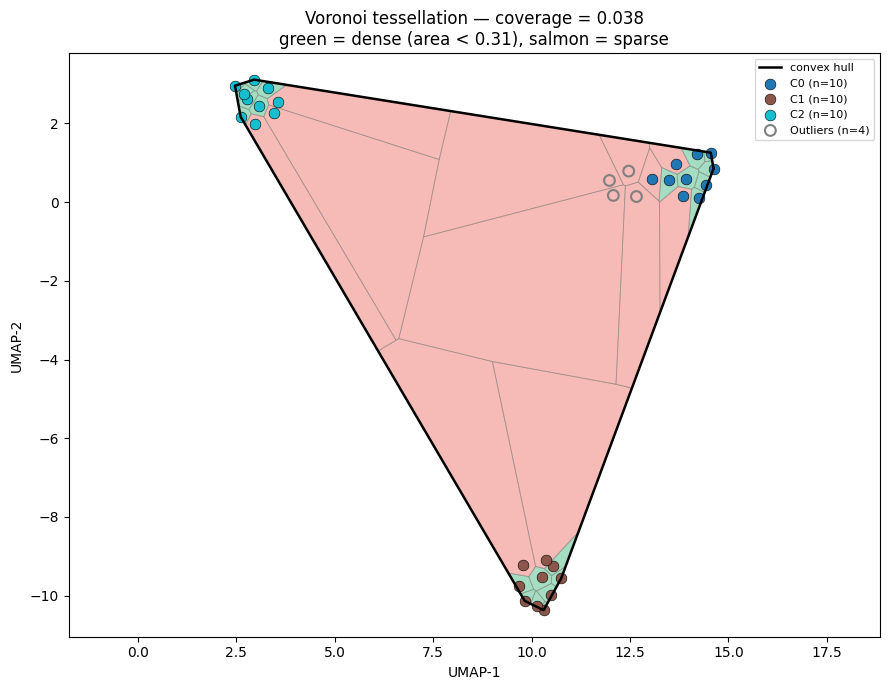

In [9]:
fig, ax = plt.subplots(figsize=(9, 7))
for i, cell in enumerate(cells):
    if cell is None: continue
    color = "#5ac18e" if dense_mask[i] else "#f0847b"
    p = MplPolygon(cell, facecolor=color, edgecolor="gray", alpha=0.55, linewidth=0.6)
    ax.add_patch(p)

# Hull outline
hull_closed = np.vstack([hull_verts, hull_verts[0]])
ax.plot(hull_closed[:, 0], hull_closed[:, 1], "k-", lw=1.8, label="convex hull")

# Points, coloured by HDBSCAN cluster; noise in hollow gray
palette = plt.cm.tab10(np.linspace(0, 1, max(len(unique_ids), 1)))
for color, cid in zip(palette, unique_ids):
    mask = labels == cid
    ax.scatter(umap_coords[mask, 0], umap_coords[mask, 1], s=60, color=color,
               edgecolor="black", linewidth=0.4, label=f"C{cid} (n={int(mask.sum())})")
noise_mask = labels == -1
if noise_mask.any():
    ax.scatter(umap_coords[noise_mask, 0], umap_coords[noise_mask, 1],
               s=60, facecolors="none", edgecolors="gray", linewidth=1.5,
               label=f"Outliers (n={int(noise_mask.sum())})")

ax.set_title(f"Voronoi tessellation — coverage = {coverage:.3f}\n"
             f"green = dense (area < {threshold:.2f}), salmon = sparse")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.legend(loc="best", fontsize=8); ax.set_aspect("equal", adjustable="datalim")
plt.tight_layout(); plt.show()

## 5. Sub-phase 3.4 — Diverse Pegasus reps + `COMMON` / `VARIATION`

### Diverse sampling

Instead of always picking the 2 nearest-centroid samples, we now mix:

- **2 nearest-centroid** (prototypes — what's typical for the cluster)
- **1 boundary** (highest centroid distance still in the cluster — the edge case)
- **1 random** (draws variance the first three might miss, seeded for reproducibility)

In [10]:
def find_cluster_representatives(labels, centroid_distance, n_nearest=PEGASUS_REPS_NEAREST,
                                 n_boundary=PEGASUS_REPS_BOUNDARY, n_random=PEGASUS_REPS_RANDOM):
    """Return {cluster_id: [sample_indices]} with up to (nearest+boundary+random) reps."""
    clusters = defaultdict(list)
    for i, cid in enumerate(labels):
        if cid == -1: continue
        clusters[int(cid)].append((float(centroid_distance[i]), i))

    out = {}
    for cid in sorted(clusters.keys()):
        sorted_rows = sorted(clusters[cid], key=lambda x: x[0])
        picks, picked = [], set()
        def _add(i):
            if i not in picked:
                picks.append(i); picked.add(i)
        # nearest
        for j in range(min(n_nearest, len(sorted_rows))):
            _add(sorted_rows[j][1])
        # boundary
        for j in range(n_boundary):
            if len(sorted_rows) - 1 - j < 0: break
            _add(sorted_rows[-(j+1)][1])
        # random (deterministic)
        remaining = [idx for _, idx in sorted_rows if idx not in picked]
        if remaining and n_random > 0:
            rng_local = random.Random(PEGASUS_RANDOM_SEED + cid)
            for _ in range(min(n_random, len(remaining))):
                pick = rng_local.choice(remaining)
                _add(pick); remaining.remove(pick)
        out[cid] = picks
    return out

reps = find_cluster_representatives(labels, centroid_distance)
for cid, idxs in reps.items():
    kinds = []
    for idx in idxs:
        d = centroid_distance[idx]
        if d == centroid_distance[labels == cid].min(): kind = "nearest"
        elif d == centroid_distance[labels == cid].max(): kind = "boundary"
        else: kind = "random"
        kinds.append(f"#{idx}(d={d:.2f},{kind})")
    print(f"cluster {cid}: {kinds}")

cluster 0: ['#13(d=0.14,nearest)', '#17(d=0.15,random)', '#10(d=0.17,boundary)', '#15(d=0.16,random)']
cluster 1: ['#6(d=0.15,nearest)', '#9(d=0.15,random)', '#2(d=0.17,boundary)', '#3(d=0.15,random)']
cluster 2: ['#26(d=0.14,nearest)', '#24(d=0.14,random)', '#23(d=0.17,boundary)', '#20(d=0.16,random)']


### The new Pegasus prompt

Instead of "describe this video in one sentence", the prompt asks for **two labelled sections**:

```
COMMON: a single concise sentence about the main activity, setting, and key objects —
        the kind of detail that would likely hold for other videos of the same topic.
VARIATION: a brief phrase (a few words) naming any distinctive element that could vary
           within a group of similar videos — unusual angle, specific subject detail,
           lighting, or timing. If nothing stands out, say 'typical example'.
```

Per-video replies are parsed into `(common, variation)`; the plugin then joins them across the 4 reps into two fields:

- `cluster_label` — joined COMMON descriptions (what the reps share)
- `cluster_diversity` — joined VARIATION notes (how they differ)

In [11]:
def parse_pegasus_response(text):
    """Split a labelled COMMON/VARIATION reply into two strings."""
    if not text: return "", ""
    cleaned = text.strip().replace("**", "").replace("__", "")
    buf = {"common": [], "variation": []}
    current = None
    for line in cleaned.splitlines():
        stripped = line.strip()
        if not stripped: continue
        upper = stripped.upper()
        if upper.startswith("COMMON:"):
            current = "common"
            rest = stripped[len("COMMON:"):].strip()
            if rest: buf[current].append(rest)
        elif upper.startswith("VARIATION:"):
            current = "variation"
            rest = stripped[len("VARIATION:"):].strip()
            if rest: buf[current].append(rest)
        elif current is not None:
            buf[current].append(stripped)
    c = " ".join(buf["common"]).strip()
    v = " ".join(buf["variation"]).strip()
    if not c and not v: c = cleaned.strip()
    return c, v

# A few example replies Pegasus might produce
examples = [
    "COMMON: A forklift driver moves a pallet in a warehouse aisle.\nVARIATION: operator makes a tight reverse turn",
    "**COMMON:** outdoor ladder climb on a construction site\n**VARIATION:** ladder tied to scaffolding, overcast lighting",
    "A worker inspects a vehicle in a garage.",  # unlabelled fallback
]
for ex in examples:
    c, v = parse_pegasus_response(ex)
    print(f"COMMON:    {c!r}")
    print(f"VARIATION: {v!r}")
    print("—" * 60)

COMMON:    'A forklift driver moves a pallet in a warehouse aisle.'
VARIATION: 'operator makes a tight reverse turn'
————————————————————————————————————————————————————————————
COMMON:    'outdoor ladder climb on a construction site'
VARIATION: 'ladder tied to scaffolding, overcast lighting'
————————————————————————————————————————————————————————————
COMMON:    'A worker inspects a vehicle in a garage.'
VARIATION: ''
————————————————————————————————————————————————————————————


In [12]:
# Simulate Pegasus on each rep and aggregate
def fake_pegasus(video_idx, cid):
    topic = ["forklift forward/reverse maneuver",
             "forklift forward/reverse maneuver",
             "worker climbing a ladder"][cid]
    variation = ["narrow aisle", "loaded pallet", "outdoor lighting",
                 "tall ladder", "hard hat visible"][video_idx % 5]
    return (f"COMMON: {topic} in a warehouse-like setting.\n"
            f"VARIATION: {variation}")

for cid, idxs in reps.items():
    commons, variations = [], []
    for idx in idxs:
        c, v = parse_pegasus_response(fake_pegasus(idx, cid))
        if c: commons.append(c)
        if v: variations.append(v)

    # cluster_label = first N-nearest COMMON descriptions, joined
    cluster_label = "; ".join(commons[:PEGASUS_REPS_NEAREST]) if commons else f"Cluster {cid}"
    # cluster_diversity = deduped VARIATION phrases
    seen, deduped = set(), []
    for v in variations:
        key = v.lower()
        if key not in seen:
            seen.add(key); deduped.append(v)
    cluster_diversity = "; ".join(deduped)

    print(f"\ncluster {cid}:")
    print(f"  cluster_label:     {cluster_label}")
    print(f"  cluster_diversity: {cluster_diversity}")


cluster 0:
  cluster_label:     forklift forward/reverse maneuver in a warehouse-like setting.; forklift forward/reverse maneuver in a warehouse-like setting.
  cluster_diversity: tall ladder; outdoor lighting; narrow aisle

cluster 1:
  cluster_label:     forklift forward/reverse maneuver in a warehouse-like setting.; forklift forward/reverse maneuver in a warehouse-like setting.
  cluster_diversity: loaded pallet; hard hat visible; outdoor lighting; tall ladder

cluster 2:
  cluster_label:     worker climbing a ladder in a warehouse-like setting.; worker climbing a ladder in a warehouse-like setting.
  cluster_diversity: loaded pallet; hard hat visible; tall ladder; narrow aisle


## 6. How the plugin wires this up

Inside the `AnalyzeCoverage` operator, stage 4 now composes these three pieces into a single `gap_report` written to `dataset.info`:

```python
gap_report = {
    "sparse_clusters":     [...],               # sorted by priority_score desc
    "category_gaps":       [...],               # flat missing leaves, priority_score per entry
    "category_hierarchy":  [                    # parent → children tree
        {
            "parent": "forklift operations",
            "n_covered": 2, "n_children": 4, "coverage": 0.5, "best_similarity": 0.97,
            "children": [
                {"category": "forward", "similarity": 0.97, "is_gap": False, ...},
                {"category": "reverse", "similarity": 0.96, "is_gap": False, ...},
                {"category": "loading", "similarity": 0.08, "is_gap": True, "priority_score": 96.0, ...},
                {"category": "turning", "similarity": 0.01, "is_gap": True, "priority_score": 97.9, ...},
            ],
        },
        ...
    ],
    "coverage_score": 0.5 * voronoi_coverage + 0.5 * category_coverage,
}
```

`ShowGapReport` renders it as a markdown report with `[Priority N/100]` badges on every gap, a per-parent breakdown, and a "Top Priority Gaps" rollup across parents. `CoveragePanel` uses the same `category_gaps` entries to drop hollow-red-diamond markers onto the UMAP scatter plot — colocated with the closest cluster's centroid — and adds two summary tables (parent coverage and per-child status).

In the sample fields themselves:

- `cluster_label` — joined `COMMON` descriptions, the "what the cluster is" summary.
- `cluster_diversity` — joined `VARIATION` notes, the "how videos in this cluster differ" summary.
- `cluster_confidence` — HDBSCAN `probabilities_` (Phase 2.2), useful as a soft gap signal for boundary points.

Together: the analysis is geometrically faithful (Voronoi), hierarchically addressable (parent → child), priority-ranked, and the clusters themselves tell you what varies inside them — not just what they have in common.